# OPD 911 Call Volume — Demand Forecasting: Baseline Model Development

Goal: forecast total 911 calls per hour, for the next 7 days, as a first step toward
capacity/staffing planning for OPD's Emergency Communications Center.

This notebook consolidates the model-development work into one place, replacing a
growing pile of one-off scripts. It covers the "sensible points" of the exploration:

1. **Model A** — baseline seasonal model (hour-of-day x day-of-week), trained on **all
   available data** (2021-2026)
2. **Model B** — adds a **holiday** feature
3. **Model C** — adds **weather** (temperature, precipitation)
4. **Model D** — the current **recommended model**: seasonal + holiday, trained only on
   **post-cutover data** (i.e. after the CAD system transition)

All four are evaluated on the same held-out 13-week window (2026-04-01 to 2026-06-30)
so they're directly comparable.

**Data prep is not repeated here** — it happens in two standalone scripts that produce
cached parquet files this notebook just loads:
- `build_harmonized_calls_table.py` -> `Data/Our Data/harmonized_calls_2021_2026.parquet`
  (harmonizes the 6 differently-shaped yearly sheets in `2021-2026current.xlsx` into one
  long table — see `Data/Our Data/2021-2026current - DATA GUIDE.md` for the full schema
  mapping and data-quality notes)
- `fetch_weather_data.py` -> `Data/Our Data/weather_oakland_2024_2026.parquet`
  (hourly Oakland weather from Open-Meteo's free historical archive API)

Re-run those two scripts only if the source data changes; everything modeling-related
lives here from now on.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from pandas.tseries.holiday import USFederalHolidayCalendar
import warnings

warnings.filterwarnings("ignore", category=UserWarning)  # noisy but harmless optimizer convergence chatter

CALLS_PARQUET = "../Data/Our Data/harmonized_calls_2021_2026.parquet"
WEATHER_PARQUET = "../Data/Our Data/weather_oakland_2024_2026.parquet"

# Fixed evaluation window used for every model below, so results are directly comparable.
TEST_START = "2026-04-01"
TEST_END = "2026-07-01"  # exclusive

# Precise CAD system cutover date (verified from the literal per-row system flag in the
# source data, not inferred) -- see DATA GUIDE.md for detail.
CAD_CUTOVER = "2024-08-01"


## Shared helpers

Building the complete hourly call-count series (with explicit zeros for silent hours), the holiday flag, and a small evaluation helper -- reused by every model below.

In [2]:
def build_hourly_counts():
    """Complete hourly call-count series with hour-of-day, day-of-week, and is_holiday."""
    df = pd.read_parquet(CALLS_PARQUET, columns=["event_time"])
    counts = df["event_time"].dt.floor("h").value_counts().sort_index()
    full_index = pd.date_range(counts.index.min(), counts.index.max(), freq="h")
    hourly = counts.reindex(full_index, fill_value=0)
    hourly.index.name = "hour"
    hourly.name = "calls"
    out = hourly.reset_index()
    out["hour_of_day"] = out["hour"].dt.hour
    out["day_of_week"] = out["hour"].dt.dayofweek

    # Holiday set = US federal holidays (as observed) UNION the actual calendar dates of
    # July 4, Halloween, and New Year's Eve every year. The union matters because the
    # *observed* federal holiday (a day off work) can fall on a different date than the
    # actual celebration that drives call volume (e.g. July 4, 2021 was a Sunday, so the
    # observed holiday was Monday July 5th, but fireworks activity happens on the actual
    # date regardless).
    start, end = out["hour"].min(), out["hour"].max()
    federal = set(USFederalHolidayCalendar().holidays(start=start, end=end).date)
    fixed_dates = set()
    for y in range(start.year, end.year + 1):
        fixed_dates.update([
            pd.Timestamp(y, 7, 4).date(),
            pd.Timestamp(y, 10, 31).date(),
            pd.Timestamp(y, 12, 31).date(),
        ])
    out["is_holiday"] = out["hour"].dt.date.isin(federal | fixed_dates).astype(int)
    return out


def evaluate(y_true, y_pred, label=""):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    print(f"  {label:35s} MAE={mae:5.2f}  RMSE={rmse:5.2f}")
    return {"label": label, "mae": mae, "rmse": rmse}


data = build_hourly_counts()
test = data[(data["hour"] >= TEST_START) & (data["hour"] < TEST_END)].copy()
print(f"Full series: {len(data):,} hours, {data['hour'].min()} to {data['hour'].max()}")
print(f"Test window (fixed, used by every model below): {len(test):,} hours, "
      f"{test['hour'].min()} to {test['hour'].max()}")

results = []  # collects one dict per model for the summary table at the end


Full series: 48,168 hours, 2021-01-01 00:00:00 to 2026-06-30 23:00:00
Test window (fixed, used by every model below): 2,184 hours, 2026-04-01 00:00:00 to 2026-06-30 23:00:00


## Model A — Baseline: seasonal only, trained on all available data (2021-2026)

The simplest reasonable starting point: a Negative Binomial GLM predicting hourly call
count from `hour_of_day * day_of_week` (a saturated 168-cell seasonal model — essentially
the historical mean per hour/weekday combination). NB rather than Poisson because
call volume is meaningfully overdispersed even within fixed hour/day-of-week cells
(variance ~2.3x the mean) — NB models that correctly, Poisson would understate
uncertainty. Trained here on the full 2021-2026 history, no filtering.


In [3]:
formula_seasonal = "calls ~ C(hour_of_day) * C(day_of_week)"

train_all = data[data["hour"] < TEST_START].copy()
model_a = smf.negativebinomial(formula_seasonal, data=train_all).fit(disp=0, maxiter=200, method="bfgs")
pred_a = model_a.predict(test)
results.append(evaluate(test["calls"].values, pred_a.values, "A: seasonal, all data (2021+)"))


  A: seasonal, all data (2021+)       MAE= 6.66  RMSE= 8.40


## Model B — + Holidays

Adds `is_holiday` (built in `build_hourly_counts` above) interacted with hour-of-day, so
holidays get their own hourly profile rather than just a flat shift. Validated
separately via leave-one-week-out testing on weeks containing July 4th and New Year's:
holiday-hours-only MAE improved ~19-20% versus the no-holiday model on those specific
weeks, at negligible cost on holiday-free weeks. Still trained on all data (2021-2026)
here, to isolate the effect of adding holidays alone.


In [4]:
formula_holiday = "calls ~ C(hour_of_day) * C(day_of_week) + C(hour_of_day) * is_holiday"

model_b = smf.negativebinomial(formula_holiday, data=train_all).fit(disp=0, maxiter=200, method="bfgs")
pred_b = model_b.predict(test)
results.append(evaluate(test["calls"].values, pred_b.values, "B: + holiday, all data (2021+)"))


  B: + holiday, all data (2021+)      MAE= 6.64  RMSE= 8.38


## Model C — + Weather

Adds hourly temperature (`temp_c`, plus a quadratic term since both very cold and very
hot conditions could plausibly push calls up) and precipitation (`precip_mm`), sourced
from Open-Meteo's free historical archive API for Oakland (`fetch_weather_data.py`).

**Weather data only covers 2024-01-01 onward**, so this model is necessarily trained on
2024+ data, not the full history like A and B.

**Caveat, confirmed by testing:** temperature is statistically significant (p<0.001) but
the effect size is small relative to hour-of-day (a 10°C swing ≈ 9% change in expected
calls, vs. hour-of-day's ~160% swing), and adding it did **not** improve held-out
accuracy — MAE was slightly *worse* than the no-weather equivalent. Kept in this
notebook as a documented, tested result (statistically real, practically not useful for
this model), not because it's recommended for production use. It would also need a
weather *forecast* (not historical actuals, which is what's used here) to run in real
7-day-ahead deployment, adding another source of error on top of not even helping with
perfect hindsight.


In [5]:
weather = pd.read_parquet(WEATHER_PARQUET)
data_w = data.merge(weather, on="hour", how="left")
data_w["temp_c2"] = data_w["temp_c"] ** 2

train_2024 = data_w[(data_w["hour"] >= "2024-01-01") & (data_w["hour"] < TEST_START)].copy()
test_w = data_w[(data_w["hour"] >= TEST_START) & (data_w["hour"] < TEST_END)].copy()

formula_weather = formula_holiday + " + temp_c + temp_c2 + precip_mm"
model_c = smf.negativebinomial(formula_weather, data=train_2024).fit(disp=0, maxiter=200, method="bfgs")
pred_c = model_c.predict(test_w)
results.append(evaluate(test_w["calls"].values, pred_c.values, "C: + weather, 2024+"))

# For reference: same formula/window without weather, to isolate weather's effect cleanly.
model_b_2024 = smf.negativebinomial(formula_holiday, data=train_2024).fit(disp=0, maxiter=200, method="bfgs")
pred_b_2024 = model_b_2024.predict(test_w)
results.append(evaluate(test_w["calls"].values, pred_b_2024.values, "B': + holiday, 2024+ (for comparison to C)"))


  C: + weather, 2024+                 MAE= 6.89  RMSE= 8.67


  B': + holiday, 2024+ (for comparison to C) MAE= 6.79  RMSE= 8.56


## Model D — Recommended: seasonal + holiday, trained on post-cutover data only

**Why not just use all available history?** The CAD (dispatch) system changed in 2024.
A per-row system flag in the source data (`P1CAD/OLDCAD`, see DATA GUIDE.md) shows an
almost single-month cutover: July 2024 is mixed, August 2024 is ~99.9% new system,
September 2024 onward is 100% new system. That transition wasn't just cosmetic —
spot-checking incident-type categories across the boundary found at least one case
(911 hang-up calls) where the *real* volume changed by ~45%, not just the label. So
training across that boundary mixes two different measurement regimes of "a call."

Restricting training to **2024-08-01 onward only** (post-cutover) was tested against
training on all of 2024+ and on the full 2021-2026 history, on this notebook's test
window, and won outright: best MAE and RMSE of the three, and roughly 40% less
systematic hour-of-day bias than the 2024+ default. This is the current recommended
model.

*(A caveat worth keeping in mind: a follow-up robustness check across two other 13-week
test periods found the "more history helps" pattern is not perfectly monotonic beyond
~3 months of data — sometimes 3 months of training data does just as well or slightly
better than using everything since the cutover. The post-cutover-only choice is a safe,
reasonable default, not a provably optimal one. Very short windows, under ~2 months,
were robustly worse in every test, so the main thing to avoid is training on too little
recent data, not necessarily maximizing how much post-cutover history is used.)*


In [6]:
train_post_cutover = data[(data["hour"] >= CAD_CUTOVER) & (data["hour"] < TEST_START)].copy()

model_d = smf.negativebinomial(formula_holiday, data=train_post_cutover).fit(disp=0, maxiter=200, method="bfgs")
pred_d = model_d.predict(test)
results.append(evaluate(test["calls"].values, pred_d.values, "D: + holiday, post-cutover only (RECOMMENDED)"))


  D: + holiday, post-cutover only (RECOMMENDED) MAE= 6.43  RMSE= 8.13


## Summary

All four (plus the reference point B') side by side, and a quick visual check of Model D against the actual test-week data.

In [7]:
summary = pd.DataFrame(results).set_index("label")
display(summary.round(3))


,mae,rmse
label,,
"A: seasonal, all data (2021+)",6.658,8.405
"B: + holiday, all data (2021+)",6.643,8.382
"C: + weather, 2024+",6.892,8.671
"B': + holiday, 2024+ (for comparison to C)",6.793,8.557
"D: + holiday, post-cutover only (RECOMMENDED)",6.430,8.134


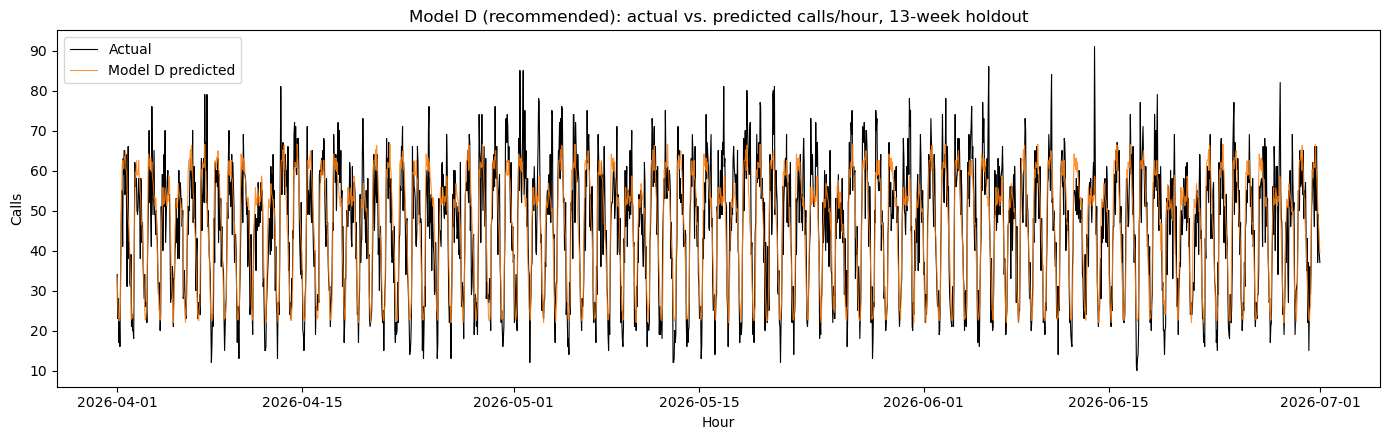

In [8]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(test["hour"], test["calls"], label="Actual", color="black", linewidth=0.8)
ax.plot(test["hour"], pred_d.values, label="Model D predicted", color="tab:orange", linewidth=0.8, alpha=0.85)
ax.set_title("Model D (recommended): actual vs. predicted calls/hour, 13-week holdout")
ax.set_xlabel("Hour")
ax.set_ylabel("Calls")
ax.legend()
fig.tight_layout()
plt.show()


## Notes on what was tried and *not* kept

For a full record of the reasoning and numbers behind these, see the `opd_demand_forecasting_scope`
project memory.

- **A linear trend term** (days-since-start, interacted with hour-of-day) was tried on top
  of Model D. It overfit within the training window and overshot badly when extrapolated
  past it — RMSE got worse, and a bias that was originally "over-predict daytime,
  under-predict night" flipped to "under-predict almost every hour." Not used.
- **Shorter, more-recent training windows** (2 weeks up to a few months) were tested against
  using all post-cutover data — consistently worse for very short windows (under ~2
  months), and inconsistent (sometimes better, sometimes worse, small differences) beyond
  ~3 months. No evidence that recency beats simply using the available post-cutover history.
- **Incident-type breakdown** was used once as a diagnostic (to check whether a residual
  bias was concentrated in specific call types — it wasn't, it's broad-based) but is not
  built out as a modeling feature. It could be a future workstream if type-level forecasts
  (e.g. separating violent/medical/property calls) become useful, but incident-type
  category labels are not fully comparable across the 2024 CAD transition (see DATA
  GUIDE.md) and would need care.
